# Install Yolo

In [ ]:
!pip install ultralytics

# Generate the model

### The model is learnd on 33 classes, inlcuding Balacony, Bathroom, Bathtub, Bedroom, Closets, Common area, Counter, Kitchen, Shower, Stairs, Toilets (46 WC shapes), Windows (17 shapes), bed, chairs, chair, doors (13 shapes), fridge, sink, stove, tables, and other objects and areas.  

In [8]:
import os
# FORCE DISABLE default Albumentations (prevents the automatic blur/noise)
os.environ["ALBUMENTATIONS_DISABLE"] = "1"

from ultralytics import YOLO

# 1. Load a fresh model
# Starting fresh is the only way to escape the "overfit" memory of previous runs
model = YOLO('yolov8n.pt')

# 2. Training with Manual Geometric Control
# This setup focuses on SHAPE and SCALE, which is what 33 floor plan classes need.
results = model.train(
    # --- Data Path ---
    data='/content/dataset/data.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,

    # --- Optimization ---
    optimizer='SGD',        # SGD is more robust for small datasets like yours
    lr0=0.01,               # Initial learning rate
    cos_lr=True,            # Smooth decay to prevent end-of-training jitter

    # --- Regularization (Anti-Overfit) ---
    dropout=0.15,           # Vital: Randomly shuts off neurons to stop "memorizing"
    weight_decay=0.001,     # Penalizes complex weights
    warmup_epochs=3.0,      # Stabilizes the model for the first 3 epochs

    # --- High-Quality Geometric Augmentation ---
    # These help the model recognize symbols without distorting the lines
    fliplr=0.5,             # Mirror left/right
    flipud=0.5,             # Mirror up/down
    scale=0.5,              # VERY IMPORTANT: Teaches symbols at different sizes
    mosaic=0.5,             # Contextual: sees symbols near walls/other objects
    mixup=0.1,              # Blends images slightly to increase difficulty

    # --- The "Sharp Line" Settings (Set to 0) ---
    # We disabled Albumentations above; these ensure YOLO's internal tools stay clean too.
    degrees=0.0,            # No rotation (keeps architectural lines straight)
    hsv_h=0.0,              # No color distortion
    hsv_s=0.0,              # No saturation distortion
    hsv_v=0.0,              # No brightness distortion (keeps lines high-contrast)
    shear=0.0,              # No tilting
    perspective=0.0,        # No 3D warping

    # --- Final Polish ---
    close_mosaic=10,        # Turn off mosaic for the last 10 epochs for precision
    plots=True              # Save results.png to analyze your loss curves
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, pl

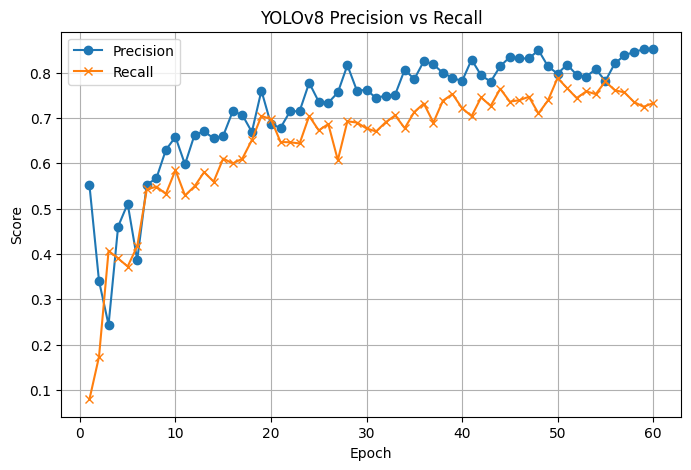

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to YOLOv8 training results
results_csv = "/content/runs/detect/train5/results.csv"

# Load the CSV
df = pd.read_csv(results_csv)

# Plot Precision and Recall
plt.figure(figsize=(8,5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', marker='o')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('YOLOv8 Precision vs Recall')
plt.legend()
plt.grid(True)
plt.show()

# Convert to ONNX deployment

In [ ]:
model.export(format='onnx')
